In [1]:
import pandas as pd

df = pd.read_csv(
    "data/raw/Global_Superstore2.csv",
    encoding="latin1"
)

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df["Shipping_Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df["Profit_Margin"] = (
    df["Profit"] / df["Sales"]
) * 100

In [2]:
average_order_value = (
    df["Sales"].sum() /
    df["Order ID"].nunique()
)

print(
    f"Average Order Value: ${average_order_value:,.2f}"
)


Average Order Value: $504.99


In [3]:
clv = (
    df.groupby("Customer ID")["Sales"]
      .sum()
)

print(
    f"Average CLV: ${clv.mean():,.2f}"
)

print(
    f"Highest CLV: ${clv.max():,.2f}"
)

Average CLV: $7,951.26
Highest CLV: $35,668.12


In [4]:
overall_margin = (
    df["Profit"].sum() /
    df["Sales"].sum()
) * 100

print(
    f"Profit Margin: {overall_margin:.2f}%"
)

Profit Margin: 11.61%


In [5]:
print(
    f"Average Shipping Days: {df['Shipping_Days'].mean():.2f}"
)

Average Shipping Days: 3.97


In [6]:
discount_analysis = (
    df.groupby("Discount")
      .agg(
          Revenue=("Sales","sum"),
          Profit=("Profit","sum")
      )
)

discount_analysis.head()

,Revenue,Profit
Discount,,
0.000,6.992411e+06,1.770695e+06
0.002,2.613956e+05,5.797658e+04
0.070,1.216169e+05,2.114850e+04
0.100,1.579606e+06,2.590642e+05
0.150,3.060298e+05,2.737590e+04


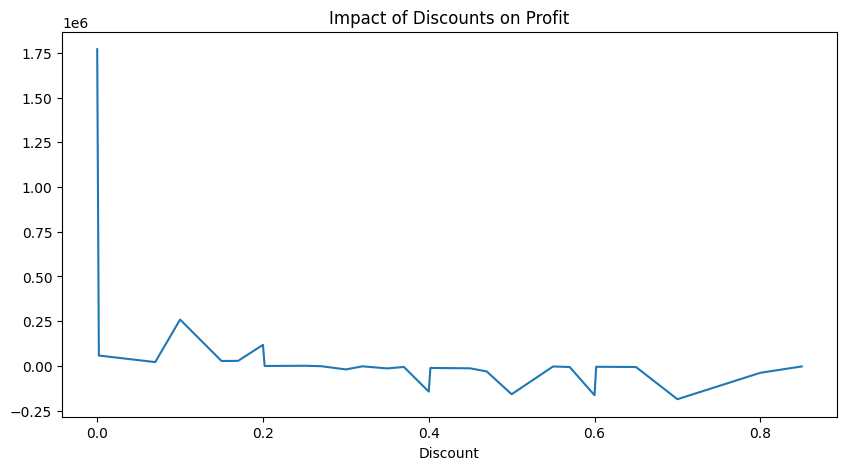

In [7]:
import matplotlib.pyplot as plt

discount_analysis["Profit"].plot(
    figsize=(10,5)
)

plt.title(
    "Impact of Discounts on Profit"
)

plt.show()

In [8]:
orders_per_customer = (
    df.groupby("Customer ID")
      .size()
)

repeat_customers = (
    orders_per_customer > 1
).sum()

repeat_rate = (
    repeat_customers /
    len(orders_per_customer)
) * 100

print(
    f"Repeat Customer Rate: {repeat_rate:.2f}%"
)

Repeat Customer Rate: 99.56%


In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/Global_Superstore2.csv",
    encoding="latin1"
)

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
).dt.strftime("%Y-%m-%d")

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
).dt.strftime("%Y-%m-%d")

df.to_csv(
    "../data/cleaned/postgres_import.csv",
    index=False
)

print(df.shape)
print(len(df.columns))
print("Export complete")

(51290, 24)
24
Export complete
